In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scipy
import scanpy as sc
import liana as li
import logging
import traceback
from anndata import AnnData, read_h5ad

import multiprocessing

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
os.chdir('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/workflow/scripts/15.Liana_bydonor/')
from Liana_Extra_Plot_Functions import *

ImportError: cannot import name '_inverse_scores' from 'liana.plotting._common' (/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/liana/plotting/_common.py)

In [4]:
from liana.plotting._common import _prep_liana_res, _check_var, _get_top_n, _filter_by, _invert_scores


In [5]:
from __future__ import annotations
import os
import sys
import numpy as np
import pandas as pd
import scipy
import scanpy as sc
import liana as li
import logging
import traceback
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

import multiprocessing
import numpy as np
import anndata
import pandas
import pandas as pd 
import plotnine as p9

from plotnine import ggplot, geom_point, aes, \
    facet_grid, labs, theme_bw, theme, element_text, element_rect, scale_size_continuous, scale_color_cmap

from liana._docs import d
from liana._constants import Keys as K, DefaultValues as V

def _filter_by2(liana_res, filter_fun):
    if filter_fun is not None:
        msk = liana_res.apply(filter_fun, axis=1).astype(bool)
        relevant_interactions = np.unique(liana_res[msk].interaction)
        liana_res = liana_res[np.isin(liana_res['interaction'], relevant_interactions)]

    return liana_res
@d.dedent
def dotplot4(adata: anndata.AnnData = None,
            uns_key = K.uns_key,
            liana_res: pandas.DataFrame = None,
            colour: str = None,
            size: str = None,
            source_labels: list = None,
            target_labels: list = None,
            top_n: int = None,
            orderby: str | None = None,
            orderby_ascending: bool | None = None,
            orderby_absolute: bool = False,
            filter_fun: callable = None,
            ligand_complex: str | None = None,
            receptor_complex: str | None = None,
            inverse_colour: bool = False,
            inverse_size: bool = False,
            cmap: str = V.cmap,
            size_range: tuple = (2, 9),
            figure_size: tuple = (8, 6),
            return_fig=V.return_fig
            ) -> ggplot:
    """
    Dotplot interactions by source and target cells

    Parameters
    ----------
    %(adata)s
    %(uns_key)s
    %(liana_res)s
    %(colour)s
    %(size)s
    %(source_labels)s
    %(target_labels)s
    %(top_n)s
    %(orderby)s
    %(orderby_ascending)s
    %(orderby_absolute)s
    %(filter_fun)s
    %(ligand_complex)s
    %(receptor_complex)s
    %(inverse_colour)s
    %(inverse_size)s
    %(cmap)s
    %(size_range)s
    %(figure_size)s

    Returns
    -------
    A `plotnine.ggplot` instance

    """
    liana_res = _prep_liana_res(adata=adata,
                                liana_res=liana_res,
                                source_labels=source_labels,
                                target_labels=target_labels,
                                ligand_complex = ligand_complex,
                                receptor_complex = receptor_complex,
                                uns_key=uns_key
                                )
    
    color_var = colour
    size_var= size
    _check_var(liana_res, var=colour, var_name='colour')
    _check_var(liana_res, var=size, var_name='size')

    liana_res = _filter_by2(liana_res, filter_fun)
    liana_res = _get_top_n(liana_res, top_n, orderby, orderby_ascending, orderby_absolute)

    # inverse sc if needed
    if inverse_colour:
        liana_res[colour] = _invert_scores(liana_res[colour])
    if inverse_size:
        liana_res[size] = _invert_scores(liana_res[size])

    print(liana_res[size])
    print(liana_res[colour])
    # generate plot
    # generate plot
    p = (ggplot(liana_res, aes(x='target', y='interaction', colour=color_var, size=size_var))
         + geom_point()
         + facet_grid('~source')
         + scale_size_continuous(range=size_range,minor_breaks=1,limits=(0,2))
         + scale_color_cmap(cmap, limits=(0,12))
         + labs(
                #color=str.capitalize(colour),
                #size=[None if x == 0 else x for x in size],
                y="Interactions (Ligand -> Receptor)",
                x="Target",
                title="Source")
         + theme_bw()
         + theme(legend_text=element_text(size=14),
                 strip_background=element_rect(fill="white"),
                 strip_text=element_text(size=15, colour="black"),
                 axis_text_y=element_text(size=10, colour="black"),
                 axis_title_y=element_text(colour="#808080", face="bold", size=15),
                 axis_text_x=element_text(size=11, face="bold", angle=90),
                 figure_size=figure_size,
                 plot_title=element_text(vjust=0, hjust=0.5, face="bold",
                                         colour="#808080", size=15)
                 )
         )
    
    if return_fig:
        return p

    p.draw()




In [6]:
os.chdir('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/')


In [7]:
import hdf5plugin
adata = sc.read_h5ad('results/2024_04_22_Immune_Metacells_combined_stored_counts.h5ad.ztsd')

In [7]:
adata.write_h5ad('results/2025_Figure3B_Liana.h5ad')

OSError: [Errno 28] Can't synchronously write data (file write failed: time = Tue Mar 18 14:51:36 2025
, filename = 'results/2025_Figure3B_Liana.h5ad', file descriptor = 77, errno = 28, error message = 'No space left on device', buf = 0x312f74000, total write size = 11872514304, bytes this sub-write = 2147483647, bytes actually written = 18446744073709551615, offset = 0)

In [8]:
filtered_pivot_df = pd.read_csv('results/2024_03_28_Log2FC_CCIs_Targets_MTC123_vs_MTC456.csv')

In [9]:
filtered_pivot_df

,Unnamed: 0,CCI,MTC_123,MTC_456,log2FC,cluster
0,0,MTC_Prolif:APOE.SORL1,3.030703,0.000000,-2.011031,MTC_123
1,1,MTC_456:APOE.SORL1,2.970016,0.000000,-1.989145,MTC_123
2,2,NEUT:S100A9.TLR4,2.539697,0.000000,-1.823626,MTC_123
3,3,MTC_123:HSPA1A.TLR4,2.519386,0.000000,-1.815324,MTC_123
4,4,NEUT:COPA.CD74,2.445202,0.000000,-1.784589,MTC_123
5,5,MTC_Prolif:C1QB.LRP1,2.426475,0.000000,-1.776725,MTC_123
6,6,MONO:LGALS1.PTPRC,2.410801,0.000000,-1.770111,MTC_123
7,7,MTC_123:APOE.SORL1,2.309835,0.000000,-1.726759,MTC_123
8,8,NEUT:S100A8.TLR4,2.307010,0.000000,-1.725527,MTC_123
9,9,B Cells:HLA-DRA.CD4,2.241298,0.000000,-1.696572,MTC_123


In [10]:
# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)

# Extracting the 'Receptor' information from the 'Ligand' column
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]

# Extracting the 'Ligand' information from the 'Ligand' column
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]

# Printing the resulting DataFrame
print(filtered_pivot_df)

# Extracting significant ligands based on the absolute log2FC threshold of 1.5
Sign_Ligands_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()

# Extracting significant receptors based on the absolute log2FC threshold of 1.5
Sign_Receptors_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()




    Unnamed: 0                      CCI   MTC_123   MTC_456    log2FC  \
0            0    MTC_Prolif:APOE.SORL1  3.030703  0.000000 -2.011031   
1            1       MTC_456:APOE.SORL1  2.970016  0.000000 -1.989145   
2            2         NEUT:S100A9.TLR4  2.539697  0.000000 -1.823626   
3            3      MTC_123:HSPA1A.TLR4  2.519386  0.000000 -1.815324   
4            4           NEUT:COPA.CD74  2.445202  0.000000 -1.784589   
5            5     MTC_Prolif:C1QB.LRP1  2.426475  0.000000 -1.776725   
6            6        MONO:LGALS1.PTPRC  2.410801  0.000000 -1.770111   
7            7       MTC_123:APOE.SORL1  2.309835  0.000000 -1.726759   
8            8         NEUT:S100A8.TLR4  2.307010  0.000000 -1.725527   
9            9      B Cells:HLA-DRA.CD4  2.241298  0.000000 -1.696572   
10          10     MTC_Prolif:APOE.LRP1  2.234624  0.000000 -1.693598   
11          11   MTC_Prolif:HLA-DRA.CD4  2.213023  0.000000 -1.683931   
12          12         MONO:S100A9.TLR4  2.201819  

In [11]:
target_plot = dotplot4(adata = adata,
        colour='magnitude_rank',
        size='specificity_rank',
        target_labels=['MTC_123', 'MTC_456'],
        inverse_size=True,
        filter_fun=lambda x: x['ligand_complex'] in Sign_Ligands_Targets  and x['receptor_complex'] in Sign_Receptors_Targets,
        inverse_colour=True,
        orderby='magnitude_rank',
        orderby_ascending=True,
        figure_size=(8, 9),
        size_range= (0,8),
        cmap = 'BuPu'
    )

6085    1.837756e+00
4599    1.837756e+00
9332    1.512322e+00
1814    1.410728e+00
7785    1.286802e+00
            ...     
1723   -9.643275e-17
1948   -9.643275e-17
1927   -9.643275e-17
1930   -9.643275e-17
2003   -9.643275e-17
Name: specificity_rank, Length: 303, dtype: float64
6085    5.617214e+00
4599    5.312278e+00
9332    3.664561e+00
1814    3.401826e+00
7785    3.201356e+00
            ...     
1723   -9.643275e-17
1948   -9.643275e-17
1927   -9.643275e-17
1930   -9.643275e-17
2003   -9.643275e-17
Name: magnitude_rank, Length: 303, dtype: float64


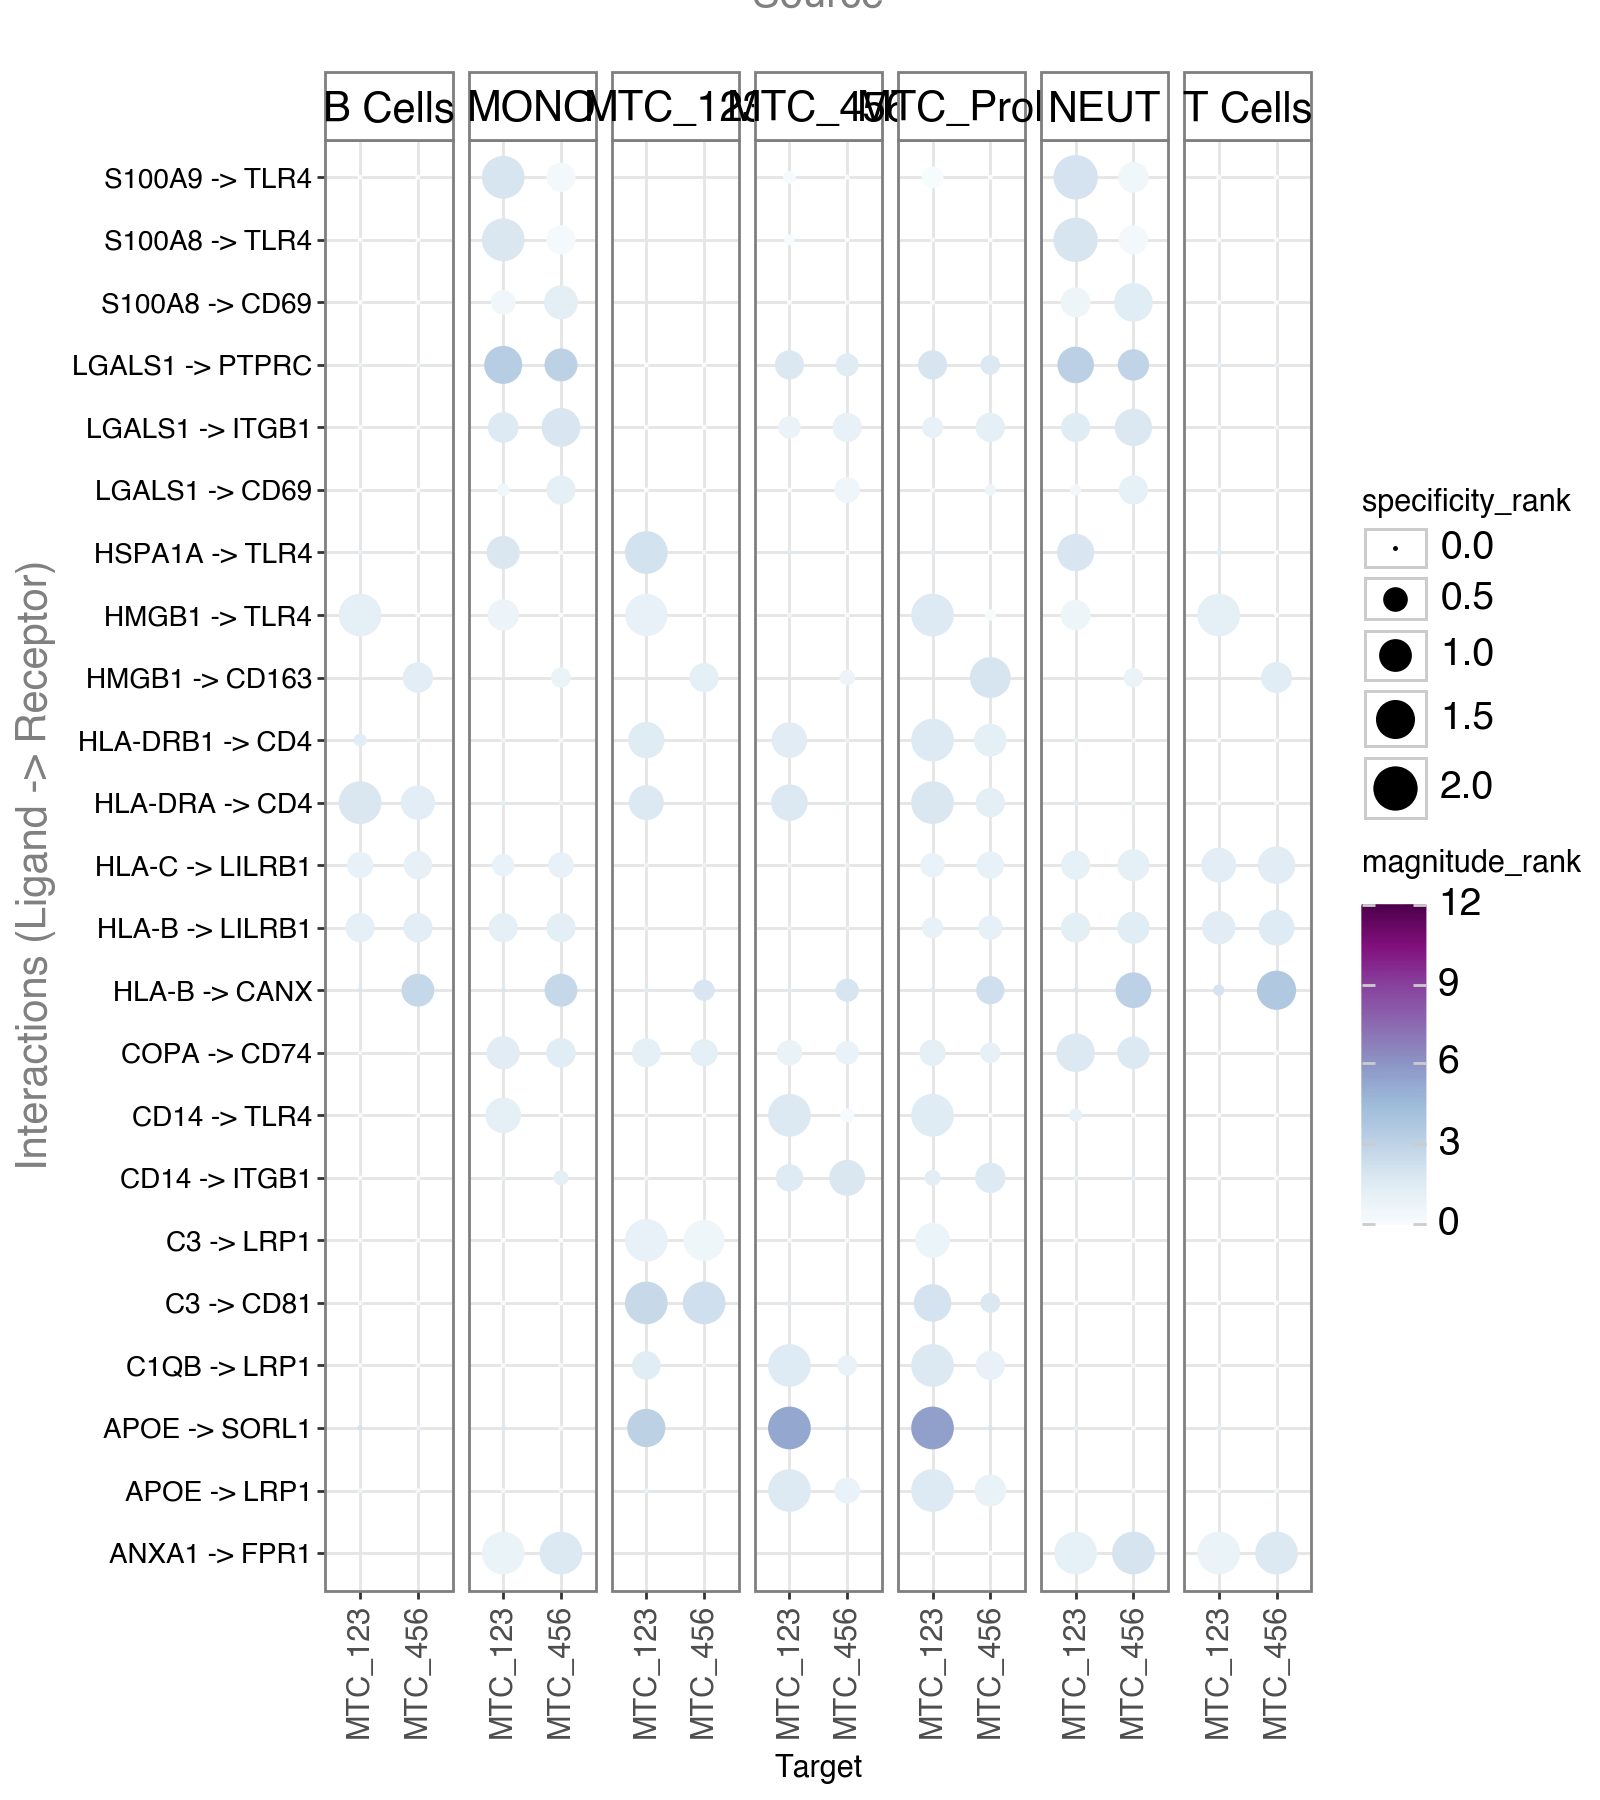

In [12]:
target_plot

In [13]:
import pandas as pd

# Copying the 'liana_res' data from 'adata.uns' into a new DataFrame 'df'
df = adata.uns["liana_res"].copy()

# Creating a condition to filter the DataFrame based on specific criteria:
# 1. 'specificity_rank' less than or equal to 0.05
# 2. 'magnitude_rank' less than or equal to 0.05
# 3. 'source' column containing values 'MTC_123' or 'MTC_456'
# Sample DataFrame
condition = (df['specificity_rank'] <=0.05) & (df['magnitude_rank'] <=0.05) & (df['source'].isin(['MTC_123','MTC_456']))
filtered_df = df[condition]
filtered_df['CCI'] = filtered_df['target'].astype(str)+':' + filtered_df['ligand_complex'].astype(str) + '.' + filtered_df['receptor_complex'].astype(str)
columns_to_keep = ['CCI', 'source','lr_means']
subset_filtered_df = filtered_df[columns_to_keep]

# Pivot the dataframe to have sources as columns
pivot_df = subset_filtered_df.pivot(index='CCI', columns='source', values='lr_means')


# Fill missing values with 0
pivot_df.fillna(0, inplace=True)

# Calculate log2FC
pivot_df['log2FC'] = np.log2(pivot_df['MTC_456'] + 1) - np.log2(pivot_df['MTC_123'] + 1)

# If you want non-existing values as zero, replace NaN values with 0
pivot_df['log2FC'].fillna(0, inplace=True)

# Reset index to make CCI a column again
pivot_df.reset_index(inplace=True)

# Print the result
print(pivot_df)

# Filter rows with absolute log2FC > 2
filtered_pivot_df= pivot_df[abs(pivot_df['log2FC']) > 1.5]

# Define a function to determine the cluster based on log2FC
def determine_cluster(row):
    if row['log2FC'] > 0:
        return 'MTC_456'
    elif row['log2FC'] < 0:
        return 'MTC_123'
    else:
        return None

# Apply the function to create the 'cluster' column
filtered_pivot_df['cluster'] = filtered_pivot_df.apply(determine_cluster, axis=1)

# Sort the dataframe by the 'log2FC' column
filtered_pivot_df = filtered_pivot_df.sort_values(by='log2FC')

# Reset the index
filtered_pivot_df.reset_index(drop=True, inplace=True)


# Splitting the values and creating new columns
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]

# print(filtered_pivot_df)

Sign_Ligands_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()
Sign_Receptors_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()

source                       CCI  MTC_123   MTC_456    log2FC
0            B Cells:HMGB1.CXCR4  2.52529  2.287482 -0.100759
1            B Cells:LGALS1.CD69  0.00000  2.092030  1.628554
2         B Cells:MIF.CD74_CXCR4  0.00000  2.483471  1.800526
3            B Cells:S100A8.CD69  0.00000  1.575006  1.364576
4              B Cells:SPP1.CD44  0.00000  3.418875  2.143679
..                           ...      ...       ...       ...
74           T Cells:LGALS1.CD69  0.00000  2.112065  1.637872
75           T Cells:S100A8.CD69  0.00000  1.595042  1.375758
76             T Cells:SPP1.CD44  0.00000  3.480267  2.163585
77      T Cells:SPP1.ITGA4_ITGB1  0.00000  3.259588  2.090714
78           T Cells:SPP1.PTGER4  0.00000  3.327195  2.113432

[79 rows x 4 columns]


/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/660223563.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/660223563.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/var/folders/_m/6gpcfwd11_56lg5zfmt0

In [14]:
source_plot = dotplot4(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            source_labels=['MTC_123', 'MTC_456'],
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in Sign_Ligands_Senders  and x['receptor_complex'] in Sign_Receptors_Senders,
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(8, 9),
            size_range= (0, 8),
            cmap = 'PuRd'
            )

5453    1.837756e+00
4543    1.837756e+00
4599    1.837756e+00
4799    1.837756e+00
5013    1.837756e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: specificity_rank, Length: 266, dtype: float64
5453    1.032488e+01
4543    8.893607e+00
4599    5.312278e+00
4799    5.183037e+00
5013    4.957746e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: magnitude_rank, Length: 266, dtype: float64


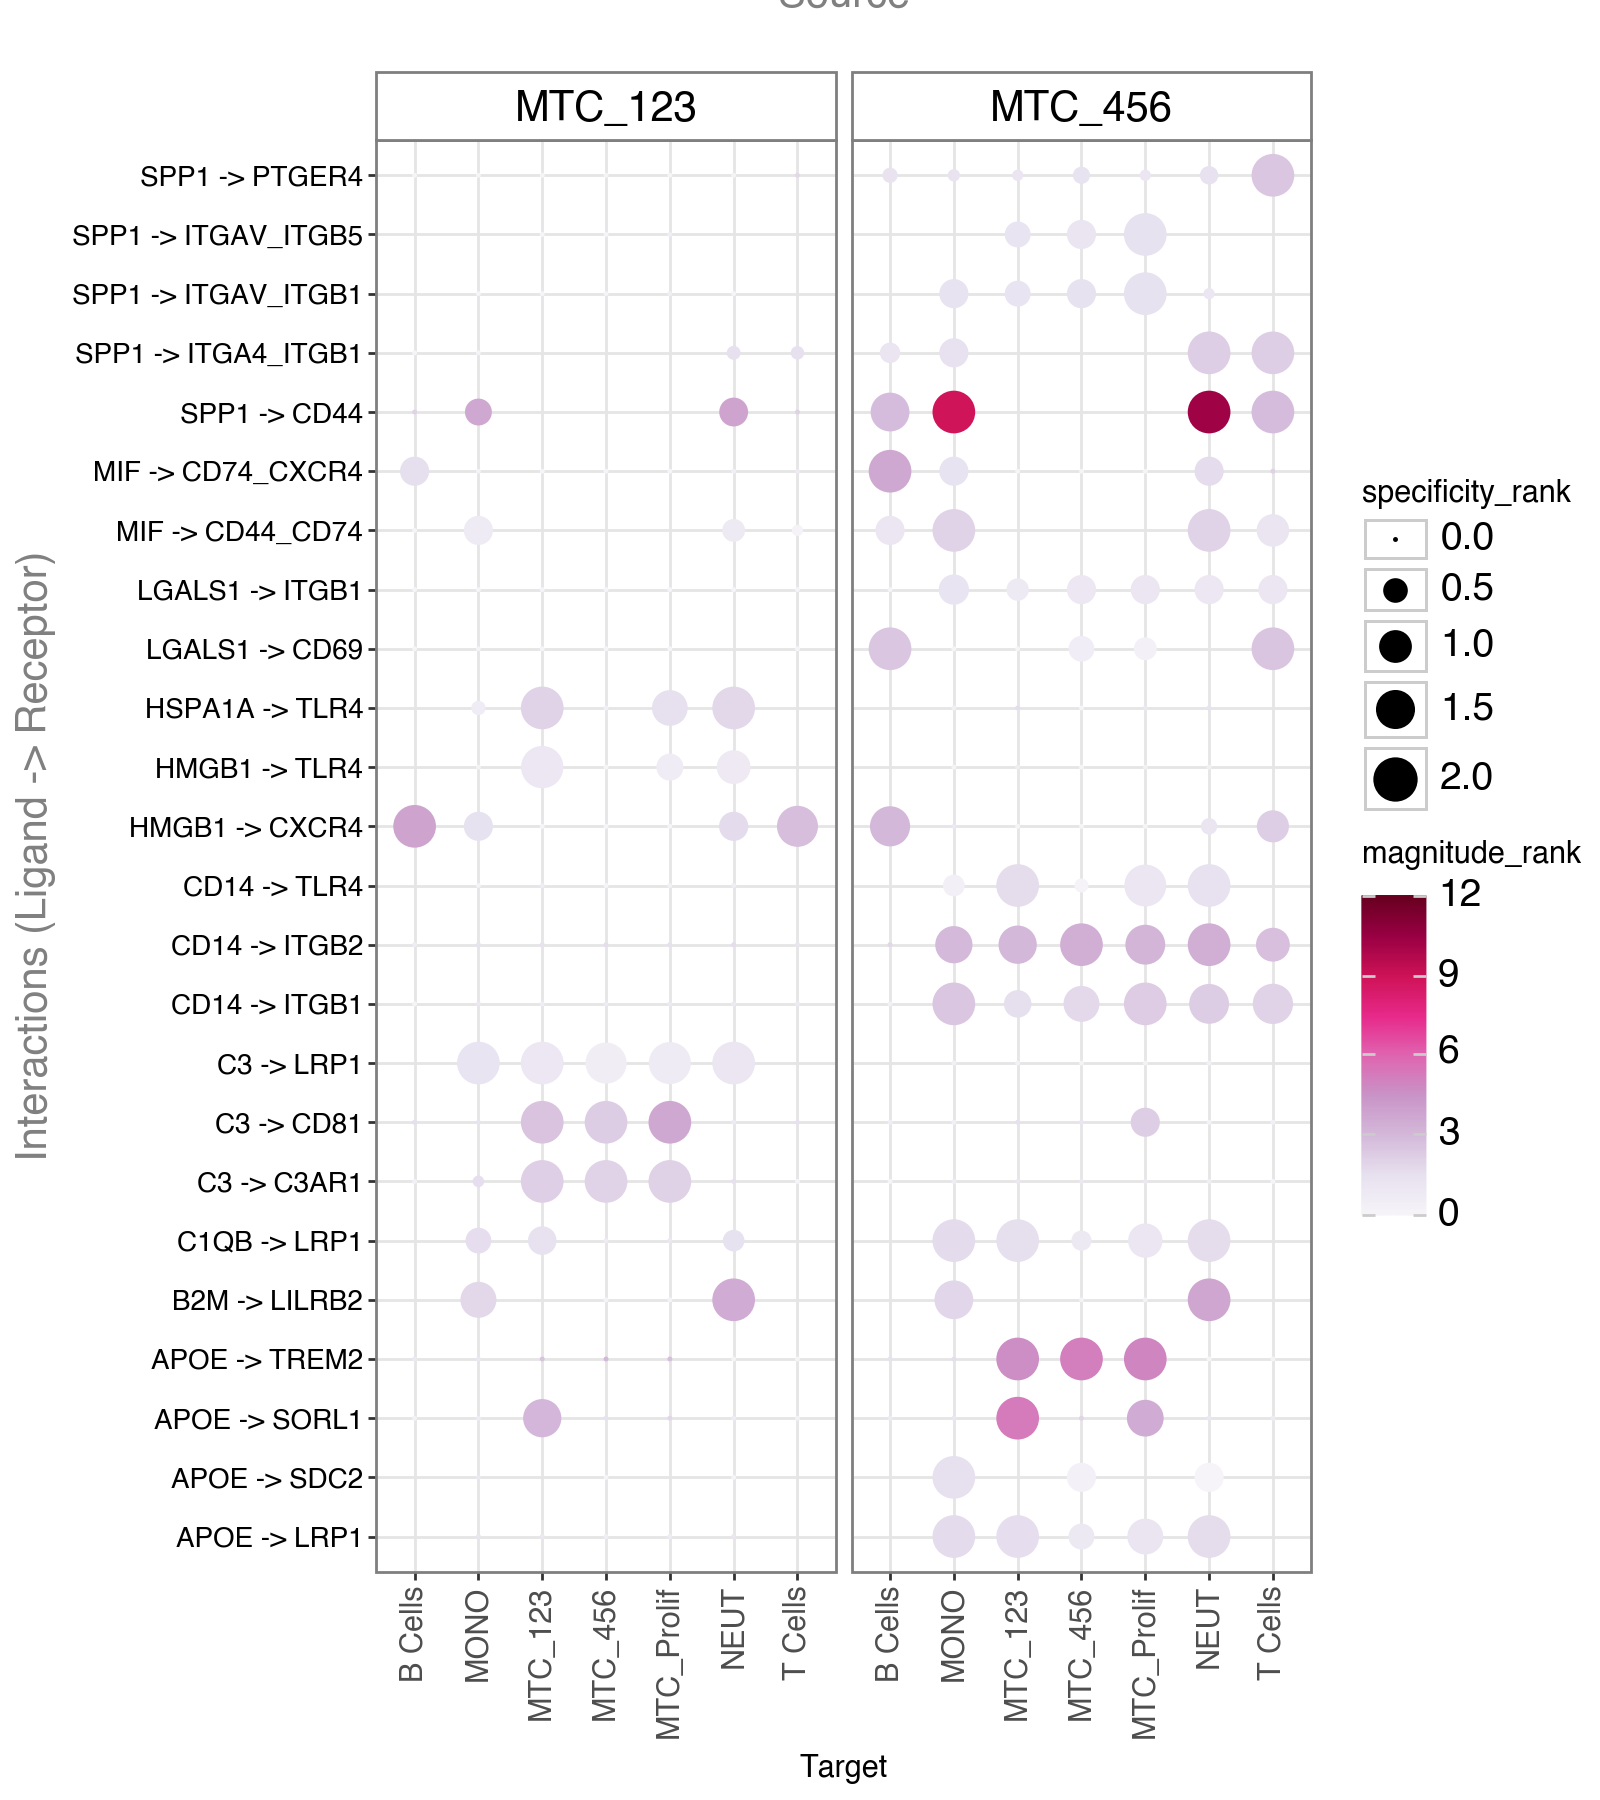

In [15]:
source_plot

In [16]:
['IL10','IL10R','IL22','IL26','IL28','IL28A','IL29']

['IL10', 'IL10R', 'IL22', 'IL26', 'IL28', 'IL28A', 'IL29']

In [17]:
IL10_subset_df = df[df["receptor_complex"].str.startswith("IL10") | df["ligand_complex"].str.startswith("IL10")]
IL10_subset_df['CCI'] = IL10_subset_df['target'].astype(str)+':' + IL10_subset_df['ligand_complex'].astype(str) + '.' + IL10_subset_df['receptor_complex'].astype(str)
# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
IL10_subset_df[['Target', 'Ligand']] = IL10_subset_df['CCI'].str.split(':', expand=True)
# Extracting the 'Receptor' information from the 'Ligand' column
IL10_subset_df['Receptor'] = IL10_subset_df['Ligand'].str.split('.').str[1]
# Extracting the 'Ligand' information from the 'Ligand' column
IL10_subset_df['Ligand'] = IL10_subset_df['Ligand'].str.split('.').str[0]


/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2394918105.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2394918105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2394918105.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docume

In [25]:
IL10_subset_df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank,CCI,Target,Ligand,Receptor
2524,MONO,NEUT,IL10,IL10RA_IL10RB,0.628430,0.000,0.393313,0.548542,0.843274,0.074834,0.831425,0.003055,0.0,0.014529,0.350196,NEUT:IL10.IL10RA_IL10RB,NEUT,IL10,IL10RA_IL10RB
7149,MTC_Prolif,T Cells,IL10,IL10RA_IL10RB,0.186635,1.000,0.034749,-0.140542,-0.317077,0.006612,0.594485,0.000000,1.0,1.000000,0.409723,T Cells:IL10.IL10RA_IL10RB,T Cells,IL10,IL10RA_IL10RB
1343,MONO,B Cells,IL10,CD27,0.653078,0.000,0.426271,2.036138,1.583242,0.253217,0.836989,0.004454,0.0,0.003560,0.412508,B Cells:IL10.CD27,B Cells,IL10,CD27
7307,NEUT,B Cells,IL10,CD27,0.575466,0.000,0.327302,1.911984,1.400862,0.194426,0.818155,0.002722,0.0,0.007110,0.475578,B Cells:IL10.CD27,B Cells,IL10,CD27
2261,MONO,MTC_Prolif,IL10,IL10RA_IL10RB,0.553600,0.000,0.293257,0.305622,0.436254,0.044223,0.809841,0.002241,0.0,0.014529,0.546340,MTC_Prolif:IL10.IL10RA_IL10RB,MTC_Prolif,IL10,IL10RA_IL10RB
8521,NEUT,NEUT,IL10,IL10RA_IL10RB,0.550818,0.000,0.301996,0.424388,0.660894,0.057459,0.812092,0.001866,0.0,0.014529,0.556901,NEUT:IL10.IL10RA_IL10RB,NEUT,IL10,IL10RA_IL10RB
7148,MTC_Prolif,T Cells,IL10,CD27,0.208746,0.000,0.042599,0.569859,0.296528,0.025305,0.618780,0.000000,1.0,0.958755,0.655440,T Cells:IL10.CD27,T Cells,IL10,CD27
1572,MONO,MONO,IL10,IL10RA_IL10RB,0.520496,0.000,0.248993,0.265447,0.447650,0.037548,0.796922,0.001275,0.0,0.018408,0.667770,MONO:IL10.IL10RA_IL10RB,MONO,IL10,IL10RA_IL10RB
2016,MONO,MTC_456,IL10,IL10RA_IL10RB,0.518162,0.000,0.245872,0.382053,0.677526,0.046781,0.795900,0.001655,0.0,0.014529,0.677915,MTC_456:IL10.IL10RA_IL10RB,MTC_456,IL10,IL10RA_IL10RB
5721,MTC_Prolif,B Cells,IL10,IL10RA_IL10RB,0.221314,0.999,0.047061,-0.088185,-0.216436,0.008954,0.630457,0.000000,1.0,1.000000,0.818424,B Cells:IL10.IL10RA_IL10RB,B Cells,IL10,IL10RA_IL10RB


2524    1.837756e+00
7149   -9.643275e-17
1343    2.448607e+00
7307    2.148131e+00
2261    1.837756e+00
8521    1.837756e+00
7148    1.829228e-02
1572    1.735004e+00
2016    1.837756e+00
5721   -9.643275e-17
6186   -9.643275e-17
8248    1.434517e+00
5577   -9.643275e-17
4898   -9.643275e-17
5383    1.323790e-01
5576    5.979307e-01
1344    4.501673e-01
4474   -9.643275e-17
4269   -9.643275e-17
4268    1.289705e+00
4694   -9.643275e-17
6408   -9.643275e-17
5720    9.078801e-01
5131   -9.643275e-17
5949   -9.643275e-17
7536    9.907193e-01
7996    1.596787e+00
7776   -9.643275e-17
6664   -9.643275e-17
6942   -9.643275e-17
1805    4.617733e-01
2729    1.512489e+00
2730    5.102446e-02
7308   -9.643275e-17
8735    1.250980e+00
8736   -9.643275e-17
Name: specificity_rank, dtype: float64
2524    4.556883e-01
7149    3.875093e-01
1343    3.845677e-01
7307    3.227787e-01
2261    2.625372e-01
8521    2.542219e-01
7148    1.834668e-01
1572    1.753728e-01
2016    1.688246e-01
5721    8.702168

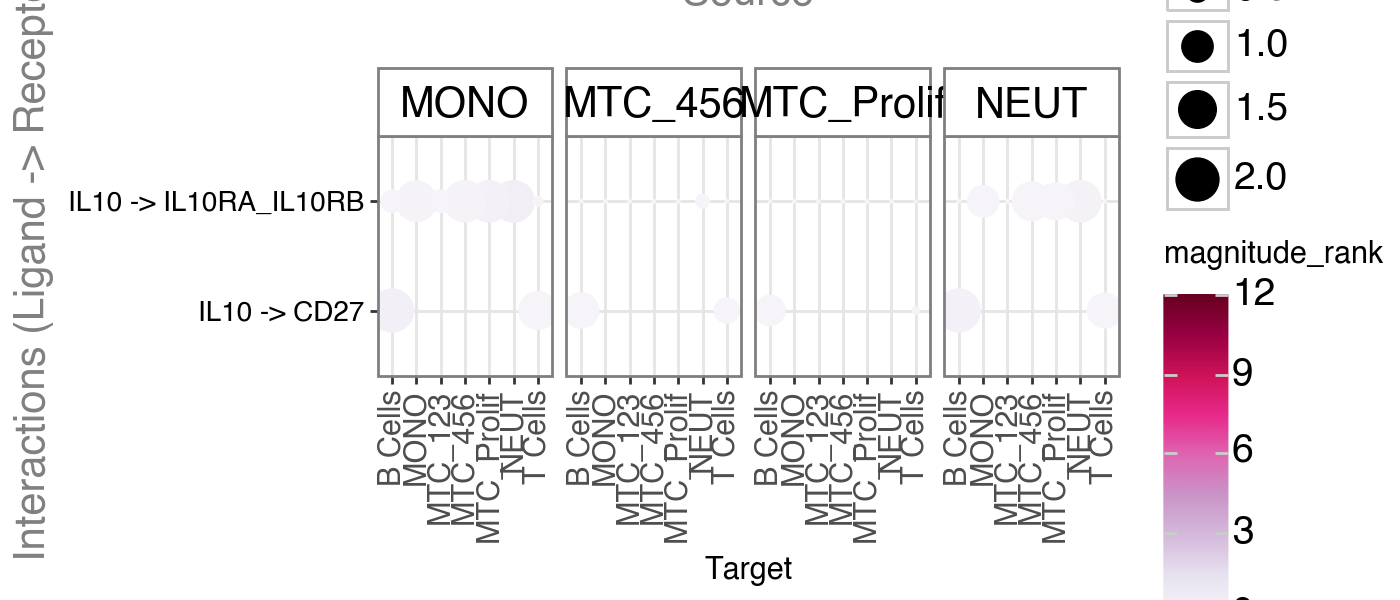

In [19]:
dotplot4(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in IL10_subset_df['Ligand'].tolist()  and x['receptor_complex'] in IL10_subset_df['Receptor'].tolist(),
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(7, 3),
            size_range= (0, 8),
            cmap = 'PuRd'
            )

# SUBSET TARGETS SELECTED

### SOURCE

In [80]:
# Copying the 'liana_res' data from 'adata.uns' into a new DataFrame 'df'
df = adata.uns["liana_res"].copy()

# Creating a condition to filter the DataFrame based on specific criteria:
# 1. 'specificity_rank' less than or equal to 0.05
# 2. 'magnitude_rank' less than or equal to 0.05
# 3. 'source' column containing values 'MTC_123' or 'MTC_456'
# Sample DataFrame
condition = (df['specificity_rank'] <=0.05) & (df['magnitude_rank'] <=0.05) & (df['source'].isin(['MTC_123','MTC_456']))
filtered_df = df[condition]
filtered_df['CCI'] = filtered_df['target'].astype(str)+':' + filtered_df['ligand_complex'].astype(str) + '.' + filtered_df['receptor_complex'].astype(str)
columns_to_keep = ['CCI', 'source','lr_means']
subset_filtered_df = filtered_df[columns_to_keep]

# Pivot the dataframe to have sources as columns
pivot_df = subset_filtered_df.pivot(index='CCI', columns='source', values='lr_means')


# Fill missing values with 0
pivot_df.fillna(0, inplace=True)

# Calculate log2FC
pivot_df['log2FC'] = np.log2(pivot_df['MTC_456'] + 1) - np.log2(pivot_df['MTC_123'] + 1)

# If you want non-existing values as zero, replace NaN values with 0
pivot_df['log2FC'].fillna(0, inplace=True)

# Reset index to make CCI a column again
pivot_df.reset_index(inplace=True)


# Filter rows with absolute log2FC > 2
filtered_pivot_df= pivot_df[abs(pivot_df['log2FC']) > 1.5]

# Define a function to determine the cluster based on log2FC
def determine_cluster(row):
    if row['log2FC'] > 0:
        return 'MTC_456'
    elif row['log2FC'] < 0:
        return 'MTC_123'
    else:
        return None

# Apply the function to create the 'cluster' column
filtered_pivot_df['cluster'] = filtered_pivot_df.apply(determine_cluster, axis=1)

# Sort the dataframe by the 'log2FC' column
filtered_pivot_df = filtered_pivot_df.sort_values(by='log2FC')

# Reset the index
filtered_pivot_df.reset_index(drop=True, inplace=True)

# Splitting the values and creating new columns
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]
Sign_Ligands_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()
Sign_Receptors_Senders = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()

/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_3941/3440451355.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_3941/3440451355.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


/var/folders/_m/6gpcfwd11_56lg5zfmt0

In [81]:
Selected_Sources = ['SPP1','LGALS1','CD14','C3','APOE']

5453    1.837756e+00
4543    1.837756e+00
4599    1.837756e+00
4799    1.837756e+00
5013    1.837756e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: specificity_rank, Length: 192, dtype: float64
5453    1.032488e+01
4543    8.893607e+00
4599    5.312278e+00
4799    5.183037e+00
5013    4.957746e+00
            ...     
2879   -9.643275e-17
2909   -9.643275e-17
2880   -9.643275e-17
3142   -9.643275e-17
3089   -9.643275e-17
Name: magnitude_rank, Length: 192, dtype: float64


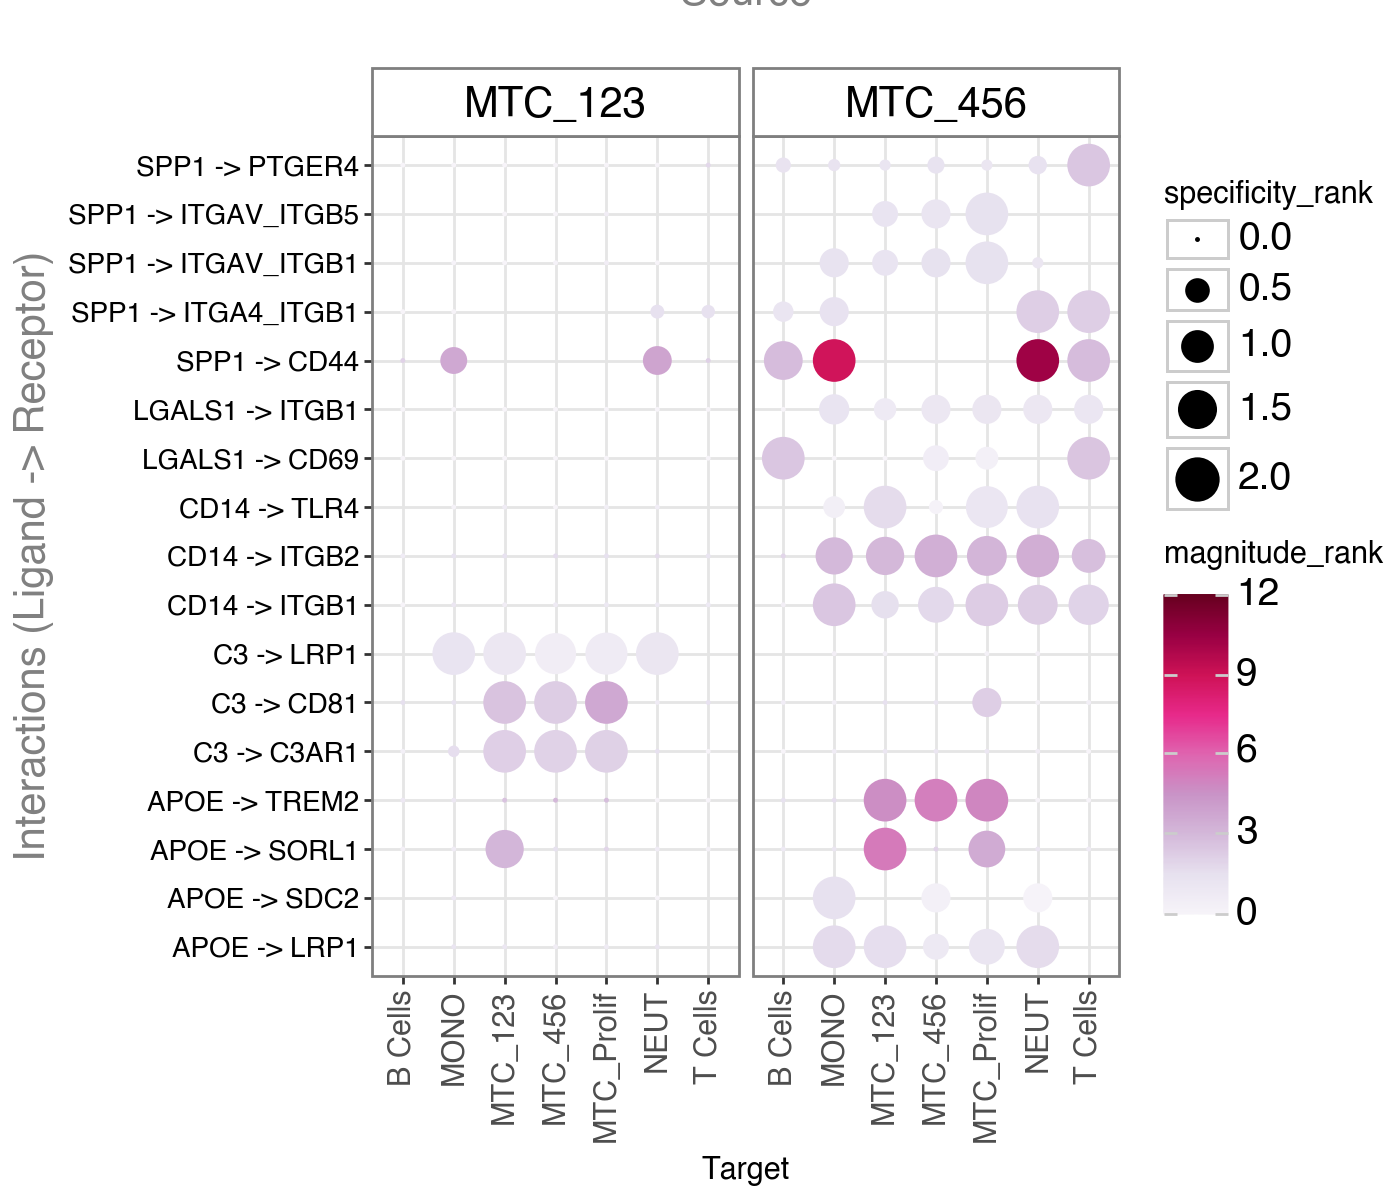

In [105]:
source_plot = dotplot4(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            source_labels=['MTC_123', 'MTC_456'],
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in Selected_Sources  and x['receptor_complex'] in Sign_Receptors_Senders,
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(7, 6),
            size_range= (0, 8),
            cmap = 'PuRd'
            )
source_plot

In [107]:
source_plot.save('/Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_Selected_Source_Figure3_B.pdf')


/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 7 x 6 in image.
/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_Selected_Source_Figure3_B.pdf


### Target

In [93]:
filtered_pivot_df = pd.read_csv('results/2024_03_28_Log2FC_CCIs_Targets_MTC123_vs_MTC456.csv')
# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
filtered_pivot_df[['Target', 'Ligand']] = filtered_pivot_df['CCI'].str.split(':', expand=True)

# Extracting the 'Receptor' information from the 'Ligand' column
filtered_pivot_df['Receptor'] = filtered_pivot_df['Ligand'].str.split('.').str[1]

# Extracting the 'Ligand' information from the 'Ligand' column
filtered_pivot_df['Ligand'] = filtered_pivot_df['Ligand'].str.split('.').str[0]

# Printing the resulting DataFrame
print(filtered_pivot_df)

# Extracting significant ligands based on the absolute log2FC threshold of 1.5
Sign_Ligands_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Ligand'].tolist()

# Extracting significant receptors based on the absolute log2FC threshold of 1.5
Sign_Receptors_Targets = filtered_pivot_df[abs(filtered_pivot_df['log2FC']) > 1.5]['Receptor'].tolist()




    Unnamed: 0                      CCI   MTC_123   MTC_456    log2FC  \
0            0    MTC_Prolif:APOE.SORL1  3.030703  0.000000 -2.011031   
1            1       MTC_456:APOE.SORL1  2.970016  0.000000 -1.989145   
2            2         NEUT:S100A9.TLR4  2.539697  0.000000 -1.823626   
3            3      MTC_123:HSPA1A.TLR4  2.519386  0.000000 -1.815324   
4            4           NEUT:COPA.CD74  2.445202  0.000000 -1.784589   
5            5     MTC_Prolif:C1QB.LRP1  2.426475  0.000000 -1.776725   
6            6        MONO:LGALS1.PTPRC  2.410801  0.000000 -1.770111   
7            7       MTC_123:APOE.SORL1  2.309835  0.000000 -1.726759   
8            8         NEUT:S100A8.TLR4  2.307010  0.000000 -1.725527   
9            9      B Cells:HLA-DRA.CD4  2.241298  0.000000 -1.696572   
10          10     MTC_Prolif:APOE.LRP1  2.234624  0.000000 -1.693598   
11          11   MTC_Prolif:HLA-DRA.CD4  2.213023  0.000000 -1.683931   
12          12         MONO:S100A9.TLR4  2.201819  

In [94]:
Selected_Targets = ['SPP1','LGALS1','CD14','C3','APOE']


6085    1.837756e+00
4599    1.837756e+00
1814    1.410728e+00
7785    1.286802e+00
3185    1.428691e+00
            ...     
1726   -9.643275e-17
1723   -9.643275e-17
1948   -9.643275e-17
1927   -9.643275e-17
1930   -9.643275e-17
Name: specificity_rank, Length: 126, dtype: float64
6085    5.617214e+00
4599    5.312278e+00
1814    3.401826e+00
7785    3.201356e+00
3185    3.102985e+00
            ...     
1726   -9.643275e-17
1723   -9.643275e-17
1948   -9.643275e-17
1927   -9.643275e-17
1930   -9.643275e-17
Name: magnitude_rank, Length: 126, dtype: float64


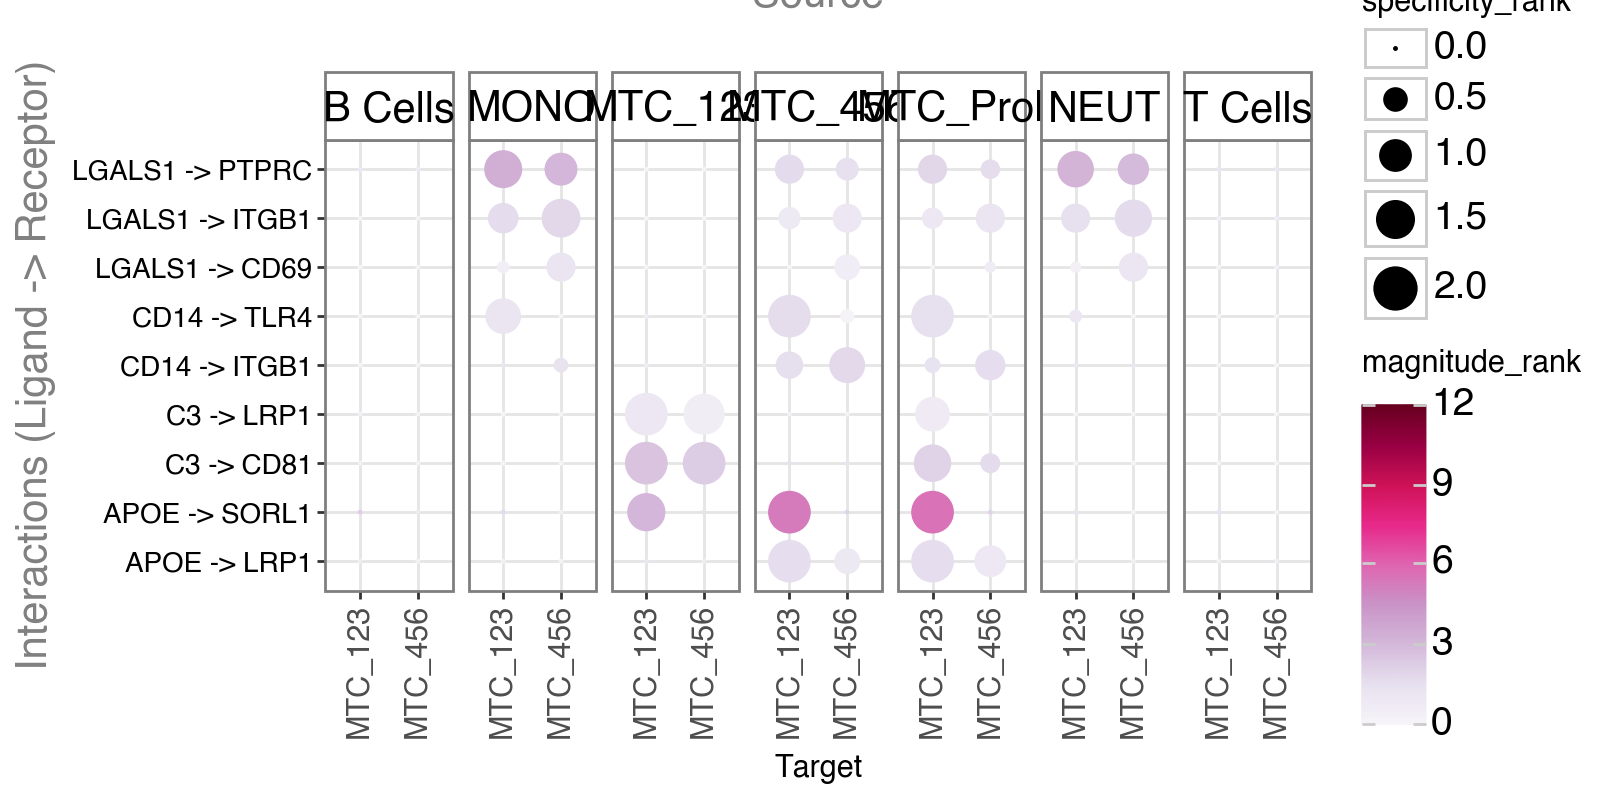

In [102]:

target_plot = dotplot4(adata = adata,
        colour='magnitude_rank',
        size='specificity_rank',
        target_labels=['MTC_123', 'MTC_456'],
        inverse_size=True,
        filter_fun=lambda x: x['ligand_complex'] in Selected_Sources  and x['receptor_complex'] in Sign_Receptors_Targets,
        inverse_colour=True,
        orderby='magnitude_rank',
        orderby_ascending=True,
        figure_size=(8, 4),
        size_range= (0,8),
        cmap = 'PuRd'
    )
target_plot

In [103]:
target_plot.save('/Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_Selected_Target_Figure3_B.pdf',dpi=300)


/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 4 in image.
/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_Selected_Target_Figure3_B.pdf


In [20]:
@d.dedent
def dotplot3(adata: anndata.AnnData = None,
            uns_key = K.uns_key,
            liana_res: pandas.DataFrame = None,
            colour: str = None,
            size: str = None,
            source_labels: list = None,
            target_labels: list = None,
            top_n: int = None,
            orderby: str | None = None,
            orderby_ascending: bool | None = None,
            orderby_absolute: bool = False,
            filter_fun: callable = None,
            ligand_complex: str | None = None,
            receptor_complex: str | None = None,
            inverse_colour: bool = False,
            inverse_size: bool = False,
            cmap: str = V.cmap,
            size_range: tuple = (2, 9),
            figure_size: tuple = (8, 6),
            return_fig=V.return_fig
            ) -> ggplot:
    """
    Dotplot interactions by source and target cells

    Parameters
    ----------
    %(adata)s
    %(uns_key)s
    %(liana_res)s
    %(colour)s
    %(size)s
    %(source_labels)s
    %(target_labels)s
    %(top_n)s
    %(orderby)s
    %(orderby_ascending)s
    %(orderby_absolute)s
    %(filter_fun)s
    %(ligand_complex)s
    %(receptor_complex)s
    %(inverse_colour)s
    %(inverse_size)s
    %(cmap)s
    %(size_range)s
    %(figure_size)s

    Returns
    -------
    A `plotnine.ggplot` instance

    """
    liana_res = _prep_liana_res(adata=adata,
                                liana_res=liana_res,
                                source_labels=source_labels,
                                target_labels=target_labels,
                                ligand_complex = ligand_complex,
                                receptor_complex = receptor_complex,
                                uns_key=uns_key
                                )
    
    color_var = colour
    size_var= size
    _check_var(liana_res, var=colour, var_name='colour')
    _check_var(liana_res, var=size, var_name='size')

    liana_res = _filter_by2(liana_res, filter_fun)
    liana_res = _get_top_n(liana_res, top_n, orderby, orderby_ascending, orderby_absolute)

    # inverse sc if needed
    if inverse_colour:
        liana_res[colour] = _invert_scores(liana_res[colour])
    if inverse_size:
        liana_res[size] = _invert_scores(liana_res[size])

    print(liana_res[size])
    print(liana_res[colour])
    # generate plot
    # generate plot
    p = (ggplot(liana_res, aes(x='target', y='interaction', colour=color_var, size=size_var))
         + geom_point()
         + facet_grid('~source')
         + scale_size_continuous(range=size_range,minor_breaks=1,limits=(0,2))
         + scale_color_cmap(cmap)
         + labs(
                #color=str.capitalize(colour),
                #size=[None if x == 0 else x for x in size],
                y="Interactions (Ligand -> Receptor)",
                x="Target",
                title="Source")
         + theme_bw()
         + theme(legend_text=element_text(size=14),
                 strip_background=element_rect(fill="white"),
                 strip_text=element_text(size=15, colour="black"),
                 axis_text_y=element_text(size=10, colour="black"),
                 axis_title_y=element_text(colour="#808080", face="bold", size=15),
                 axis_text_x=element_text(size=11, face="bold", angle=90),
                 figure_size=figure_size,
                 plot_title=element_text(vjust=0, hjust=0.5, face="bold",
                                         colour="#808080", size=15)
                 )
         )
    
    if return_fig:
        return p

    p.draw()




In [23]:
il10_targ = dotplot3(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in IL10_subset_df['Ligand'].tolist()  and x['receptor_complex'] in IL10_subset_df['Receptor'].tolist(),
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(9, 4),
            size_range= (0, 8),
            cmap = 'PuRd'
            )

2524    1.837756e+00
7149   -9.643275e-17
1343    2.448607e+00
7307    2.148131e+00
2261    1.837756e+00
8521    1.837756e+00
7148    1.829228e-02
1572    1.735004e+00
2016    1.837756e+00
5721   -9.643275e-17
6186   -9.643275e-17
8248    1.434517e+00
5577   -9.643275e-17
4898   -9.643275e-17
5383    1.323790e-01
5576    5.979307e-01
1344    4.501673e-01
4474   -9.643275e-17
4269   -9.643275e-17
4268    1.289705e+00
4694   -9.643275e-17
6408   -9.643275e-17
5720    9.078801e-01
5131   -9.643275e-17
5949   -9.643275e-17
7536    9.907193e-01
7996    1.596787e+00
7776   -9.643275e-17
6664   -9.643275e-17
6942   -9.643275e-17
1805    4.617733e-01
2729    1.512489e+00
2730    5.102446e-02
7308   -9.643275e-17
8735    1.250980e+00
8736   -9.643275e-17
Name: specificity_rank, dtype: float64
2524    4.556883e-01
7149    3.875093e-01
1343    3.845677e-01
7307    3.227787e-01
2261    2.625372e-01
8521    2.542219e-01
7148    1.834668e-01
1572    1.753728e-01
2016    1.688246e-01
5721    8.702168

In [24]:
il10_targ.save('/Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_IL10.png',dpi=300)

/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 9 x 4 in image.
/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_IL10.png


In [1]:
il10_targ

NameError: name 'il10_targ' is not defined

In [36]:
start_with_cci = ("IL10", "IFN", "IL","C3","C5")  # Tuple of prefixes

IL10_subset_df = df[
    df["receptor_complex"].str.startswith(start_with_cci) | 
    df["ligand_complex"].str.startswith(start_with_cci)
]

IL10_subset_df['CCI'] = IL10_subset_df['target'].astype(str)+':' + IL10_subset_df['ligand_complex'].astype(str) + '.' + IL10_subset_df['receptor_complex'].astype(str)
# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
IL10_subset_df[['Target', 'Ligand']] = IL10_subset_df['CCI'].str.split(':', expand=True)
# Extracting the 'Receptor' information from the 'Ligand' column
IL10_subset_df['Receptor'] = IL10_subset_df['Ligand'].str.split('.').str[1]
# Extracting the 'Ligand' information from the 'Ligand' column
IL10_subset_df['Ligand'] = IL10_subset_df['Ligand'].str.split('.').str[0]


/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2857014631.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2857014631.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_10945/2857014631.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [37]:
IL10_subset_df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank,CCI,Target,Ligand,Receptor
3606,MTC_123,MTC_Prolif,C3,CD81,2.489492,0.00,6.197558,0.613063,1.012610,0.103676,0.951405,0.164291,0.0,0.014529,0.000208,MTC_Prolif:C3.CD81,MTC_Prolif,C3,CD81
6557,MTC_Prolif,MTC_Prolif,C3,CD81,2.221421,0.00,4.864908,0.422187,0.377212,0.081383,0.945492,0.131250,0.0,0.014529,0.001359,MTC_Prolif:C3.CD81,MTC_Prolif,C3,CD81
3204,MTC_123,MTC_123,C3,CD81,2.134610,0.00,4.427862,0.350385,0.840338,0.074072,0.943015,0.122527,0.0,0.014529,0.002406,MTC_123:C3.CD81,MTC_123,C3,CD81
3396,MTC_123,MTC_456,C3,CD81,1.996917,0.00,3.741225,0.248478,0.672762,0.062585,0.938315,0.100406,0.0,0.014529,0.005561,MTC_456:C3.CD81,MTC_456,C3,CD81
5035,MTC_456,MTC_Prolif,C3,CD81,1.971399,0.00,3.621981,0.244163,-0.041615,0.060591,0.937371,0.091248,0.0,0.175529,0.006379,MTC_Prolif:C3.CD81,MTC_Prolif,C3,CD81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2019,MONO,MTC_456,IL1B,ADRB2,0.820008,1.00,0.441157,-0.269194,-0.882859,0.021365,0.839317,0.000000,1.0,1.000000,1.000000,MTC_456:IL1B.ADRB2,MTC_456,IL1B,ADRB2
2017,MONO,MTC_456,IL16,CD4,0.311093,1.00,0.076195,-0.155285,-0.412352,0.011921,0.684624,0.000000,1.0,1.000000,1.000000,MTC_456:IL16.CD4,MTC_456,IL16,CD4
8736,NEUT,T Cells,IL10,IL10RA_IL10RB,0.354551,0.00,0.100492,0.128058,0.323521,0.019120,0.713715,0.000000,1.0,1.000000,1.000000,T Cells:IL10.IL10RA_IL10RB,T Cells,IL10,IL10RA_IL10RB
8737,NEUT,T Cells,IL1B,ADRB2,1.135045,0.99,0.674537,-0.085586,-0.323173,0.032667,0.865933,0.000000,1.0,1.000000,1.000000,T Cells:IL1B.ADRB2,T Cells,IL1B,ADRB2


In [40]:
il10_targ = dotplot3(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in IL10_subset_df['Ligand'].tolist()  
                                 and x['receptor_complex'] in IL10_subset_df['Receptor'].tolist(),
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(15, 6),
            size_range= (0, 8),
            cmap = 'PuRd'
            )

3606    1.837756e+00
6557    1.837756e+00
3204    1.837756e+00
3396    1.837756e+00
5035    7.556504e-01
            ...     
2019   -9.643275e-17
2017   -9.643275e-17
8736   -9.643275e-17
8737   -9.643275e-17
7305    7.556504e-01
Name: specificity_rank, Length: 679, dtype: float64
3606    3.682866e+00
6557    2.866762e+00
3204    2.618732e+00
3396    2.254838e+00
5035    2.195240e+00
            ...     
2019   -9.643275e-17
2017   -9.643275e-17
8736   -9.643275e-17
8737   -9.643275e-17
7305   -9.643275e-17
Name: magnitude_rank, Length: 679, dtype: float64


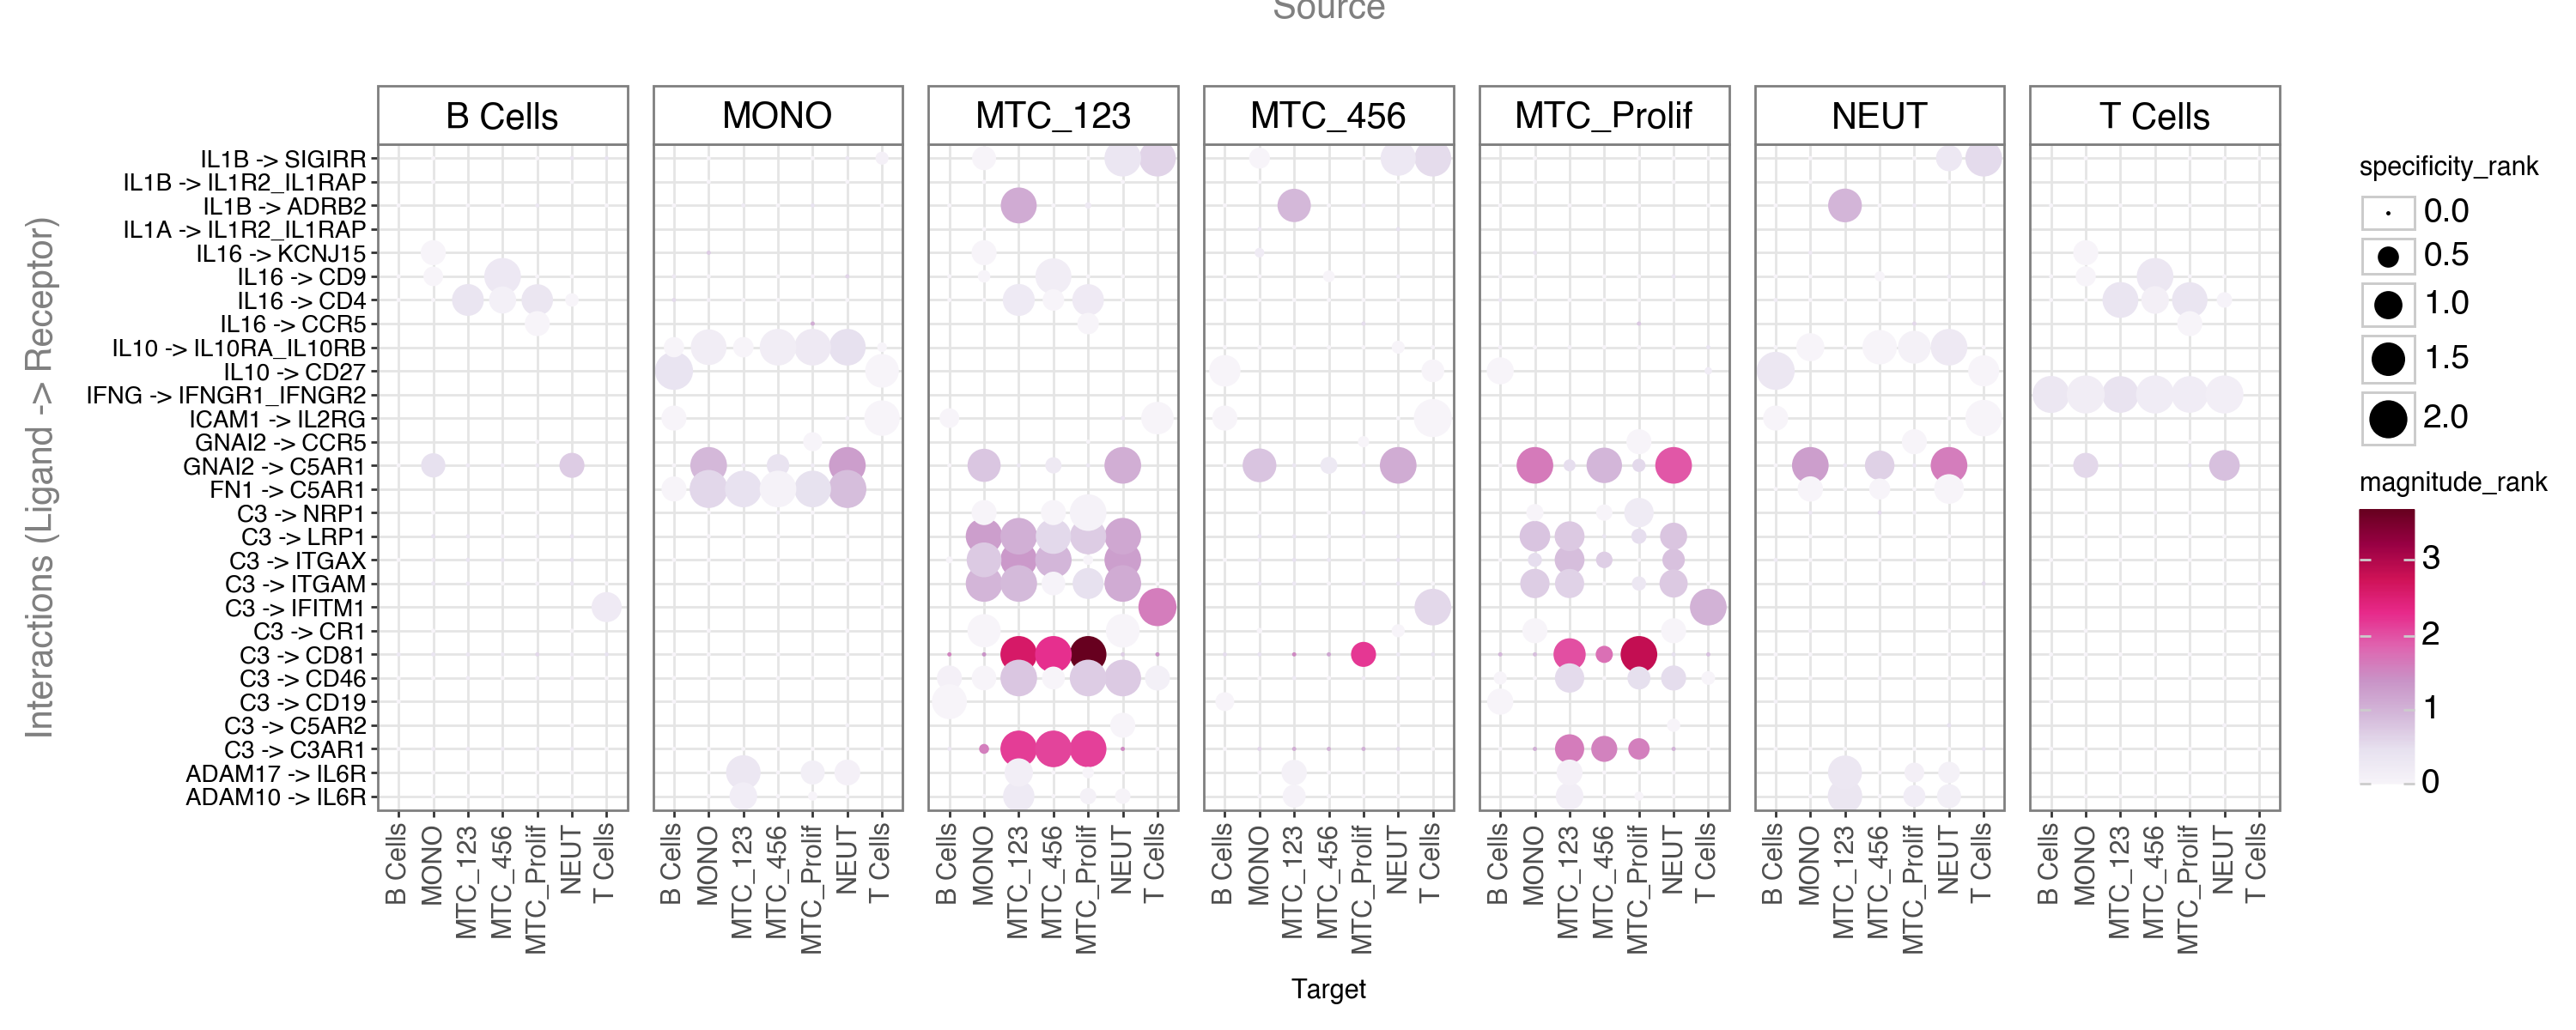

In [41]:
il10_targ

In [42]:
il10_targ.save('/Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_ALL_IL.png',dpi=300)


/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 15 x 6 in image.
/opt/homebrew/anaconda3/envs/2025_Liana/lib/python3.10/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: /Users/dimitrioskyriakis/Documents/Projects/scMyeloids_ICH/Paper_Figures/Figure3/2025_ALL_IL.png
